# Computer Exercise 15.19 — Problem 2 (Noisy-Net $\sigma_W$ Annealing Schedule)

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7e) 확장 사례연구
> **단원**: §15.19 Distributional RL — parameter-noise exploration 의 explicit annealing
> **주 참고**:
> - Fortunato et al. (2018), *Noisy Networks for Exploration*, ICLR
> - Hessel et al. (2018), *Rainbow: Combining Improvements in DQN*, AAAI (Rainbow 6-요소 원 구성)
> - Day 84–85 §15.17–§15.18 자체 관찰: +Noisy 단독이 baseline 대비 $31\times$ 시드편차 압축
> **풀이 일자**: 2026-08-04
> **언어**: 한국어 본문 + 영문 그래프 라벨


## 1. 문제 (원문)

> A **Factorized Noisy Linear** layer parameterises its weight as
> $$
>   W = \mu_W + \sigma_W \odot (f(\epsilon_{\mathrm{in}}) \otimes f(\epsilon_{\mathrm{out}})),
>   \qquad f(x) = \operatorname{sign}(x)\sqrt{|x|},
> $$
> and similarly for its bias, with $\epsilon_\bullet \sim \mathcal N(0, 1)$ freshly sampled every
> forward pass (Fortunato et al. 2018). $\mu_W, \sigma_W$ are learned by gradient descent; there
> is no explicit exploration schedule — $\sigma_W$ shrinks only as gradient of the loss carries
> variance information back to it.
>
> **Task.** Introduce an explicit **multiplicative anneal**
> $$
>   \sigma_W \gets \alpha \cdot \sigma_W, \qquad \alpha = 0.999,
> $$
> applied once per gradient step (equivalent to $\sigma_W^{(t)} = \sigma_W^{(0)} \alpha^t$).
> Compare three regimes:
> (i) **no-anneal** ($\alpha = 1.0$, gradient-only shrinkage),
> (ii) **soft anneal** ($\alpha = 0.999$, $\approx 1000$-step half-life),
> (iii) **aggressive anneal** ($\alpha = 0.99$, $\approx 100$-step half-life),
> on a small stochastic MDP with fixed budget of 4000 steps. Measure the effective
> noise magnitude $\lVert \sigma_W \rVert_2 / \sqrt{d}$, the effective exploration probability
> (variance of predicted Q induced by noise), the greedy-value tracking error, and the
> per-episode return.

### 한국어 풀이용 정리

Fortunato et al. (2018) 의 Noisy Linear 는 **parameter noise 를 파라미터로 학습**시키므로
gradient 가 손실 감소에 도움이 될 때만 $\sigma_W$ 를 줄인다. 그러나 실전에서는

1. 초기에는 uniform 하게 큰 $\sigma_W$ 로 광범위 탐색이 필요하고,
2. 어느 시점부터는 exploitation 을 위해 noise 를 줄여야 하며,
3. gradient-only shrinkage 는 (a) 보상 신호가 sparse 하거나 (b) 학습 초기부터 signal 이 안
   흐르는 경우 $\sigma_W$ 가 학습 내내 큰 상태로 남아있을 수 있다 (Day 85 Problem 3 의
   $-49.3$ 음의 시너지 진단의 한 가지 요소로 지목된 문제).

이 문제에서는 explicit multiplicative annealing $\sigma_W \leftarrow \alpha\sigma_W$
($\alpha \in \{1.0, 0.999, 0.99\}$) 을 도입해

* effective noise magnitude $\lVert\sigma_W\rVert_2/\sqrt d$
* Noisy Q 의 표본 표준편차 $\mathrm{std}_\epsilon[\tilde Q]$
* Greedy-value tracking error $|\bar{\tilde Q} - Q^\ast|$
* Per-episode return

네 축을 비교한다. 소규모 stochastic bandit-like MDP (5-arm, Gaussian noise) 로 구성.


## 2. 수학적 배경

### 2.1 Factorized Noisy Linear layer

$W \in \mathbb R^{m\times n}$ 를 $\mu_W + \sigma_W \odot E$ 로 파라미터화, $E$ 는
$\epsilon_{\mathrm{in}} \in \mathbb R^n$, $\epsilon_{\mathrm{out}} \in \mathbb R^m$ 두 개
독립 표본에서

$$
E_{ij} = f(\epsilon_{\mathrm{out},i}) \, f(\epsilon_{\mathrm{in},j}), \qquad
f(x) = \operatorname{sign}(x)\sqrt{|x|}.
$$

이 factorization 으로 표본 노이즈의 자유도를 $mn$ 에서 $m+n$ 으로 줄인다.

### 2.2 Explicit multiplicative annealing

각 gradient step 마다

$$
\boxed{\;\sigma_W^{(t+1)} = \alpha \, \sigma_W^{(t)}, \qquad \alpha \in (0,1].\;}
$$

$\alpha^T = 0.5$ 인 half-life:

$$
T_{1/2}(\alpha) = \frac{\log 0.5}{\log \alpha}.
$$

$\alpha = 0.999 \Rightarrow T_{1/2} \approx 693$, $\alpha = 0.99 \Rightarrow T_{1/2} \approx 69$.
$\alpha = 1.0$ 은 gradient-only.

### 2.3 Effective noise magnitude 와 Q variance

$\lVert\sigma_W\rVert_2 / \sqrt d$ ($d = mn$) 는 파라미터 공간의 rms 노이즈. Noisy Q 의
sampling variance 는 대략

$$
\operatorname{Var}_\epsilon[\tilde Q(s,a)]
\;\approx\; \lVert \sigma_W \odot \nabla_W Q(s,a) \rVert^2 \;+\; \text{bias term},
$$

정성적으로는 $\lVert\sigma_W\rVert$ 가 클수록 $\tilde Q$ 표준편차가 크고, exploration
확률이 크다. Annealing 은 이 exploration 을 시간에 따라 감쇠시킨다.

### 2.4 관찰 축과 예측

$\alpha = 1$: gradient-only. Return 학습 signal 이 약하면 $\sigma_W$ 감소 실패,
exploration ↔ exploitation 전환 실패. Return 편차 큼.

$\alpha = 0.999$: 소프트 감쇠. 초기 exploration → 후기 exploitation 명시화.
Tracking error 안정 감소 기대.

$\alpha = 0.99$: 공격적 감쇠. 초기 100-스텝 만에 noise 소진. exploration 부족
$\Rightarrow$ local optimum 위험.


## 3. 풀이 흐름

1. Factorized Noisy Linear 구현 ($\mu_W, \sigma_W$ 학습가능; $f(x)$ factorised noise).
2. 5-arm stochastic MDP: 각 arm 이 서로 다른 mean, 공통 noise scale 로 reward.
3. Noisy-QNet: 1-layer noisy linear from constant input to $Q \in \mathbb R^5$.
4. Semi-gradient MSE update on $\tilde Q(a) \to r_t$.
5. 세 $\alpha$ 값에 대해 (i) $\lVert\sigma_W\rVert_2/\sqrt d$ 궤적, (ii) sampling std of
   $\tilde Q$ (fresh noise), (iii) $|\bar{\tilde Q}(a^\ast) - Q^\ast(a^\ast)|$, (iv) rolling
   return 을 기록.
6. 5-시드 평균 + 표준편차. 표 + 그래프.
7. 결과 해석: $\alpha$ 별 exploration → exploitation 전환의 명시성.


In [1]:
import os
os.environ.setdefault('MPLCONFIGDIR', '/tmp/mplcache')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RNG_SEED = 86201
K_ARMS   = 5
Q_STAR   = np.array([+1.0, +0.6, -0.2, +0.4, +1.2])   # arm-4 optimal (1.2)
REWARD_NOISE = 0.3
NUM_STEPS = 4000
LR       = 5e-3

def f_noise(x):
    return np.sign(x) * np.sqrt(np.abs(x))

print('optimal arm:', int(np.argmax(Q_STAR)), 'Q*=', float(Q_STAR.max()))

optimal arm: 4 Q*= 1.2


In [2]:
class NoisyLinear:
    def __init__(self, in_dim, out_dim, sigma_init=0.5, rng=None):
        self.in_dim, self.out_dim = in_dim, out_dim
        rng = rng or np.random.default_rng(0)
        bound = 1.0 / np.sqrt(in_dim)
        self.mu_W    = rng.uniform(-bound, bound, size=(out_dim, in_dim))
        self.mu_b    = np.zeros(out_dim)
        self.sig_W   = np.full_like(self.mu_W, sigma_init / np.sqrt(in_dim))
        self.sig_b   = np.full_like(self.mu_b, sigma_init / np.sqrt(in_dim))
        self.rng     = rng

    def sample_noise(self):
        eps_in  = self.rng.standard_normal(self.in_dim)
        eps_out = self.rng.standard_normal(self.out_dim)
        f_in    = f_noise(eps_in)
        f_out   = f_noise(eps_out)
        self.E_W = np.outer(f_out, f_in)   # (out, in)
        self.E_b = f_out                   # (out,)

    def forward(self, x):
        W = self.mu_W + self.sig_W * self.E_W
        b = self.mu_b + self.sig_b * self.E_b
        return W @ x + b

    def backward_mse(self, x, target, pred, lr):
        # target/pred shape (out,). MSE loss L = 0.5 * ||pred - target||^2 wrt effective W,b.
        # d L / d y_i = pred_i - target_i.  y = W x + b.
        dy    = pred - target
        # gradients of mu_W and sig_W (W = mu + sig*E => dW/dmu = 1, dW/dsig = E)
        dW    = np.outer(dy, x)             # (out, in)
        db    = dy
        self.mu_W  -= lr * dW
        self.mu_b  -= lr * db
        # noise-modulated sigma gradient
        self.sig_W -= lr * (dW * self.E_W)
        self.sig_b -= lr * (db * self.E_b)

    def anneal(self, alpha):
        self.sig_W *= alpha
        self.sig_b *= alpha

    def sigma_rms(self):
        # rms noise across weight matrix
        s = np.concatenate([self.sig_W.ravel(), self.sig_b.ravel()])
        return float(np.sqrt(np.mean(s**2)))

    def q_sample_std(self, x, n_samples=64):
        # measure std of predicted Q across fresh noise draws (fixed mu,sig)
        vals = np.zeros((n_samples, self.out_dim))
        for k in range(n_samples):
            self.sample_noise()
            vals[k] = self.forward(x)
        return vals.std(axis=0)

In [3]:
def run_experiment(alpha, seed):
    rng = np.random.default_rng(seed)
    net = NoisyLinear(in_dim=1, out_dim=K_ARMS, sigma_init=0.5, rng=rng)
    x = np.array([1.0])
    sig_hist, qstd_hist, track_err, returns = [], [], [], []
    ep_return, ep_len = 0.0, 0
    for t in range(NUM_STEPS):
        net.sample_noise()
        q_tilde = net.forward(x)
        a = int(np.argmax(q_tilde))
        r = Q_STAR[a] + REWARD_NOISE * rng.standard_normal()
        # semi-gradient MSE: only chosen arm updates
        target = q_tilde.copy(); target[a] = r
        net.backward_mse(x, target, q_tilde, LR)
        net.anneal(alpha)
        ep_return += r; ep_len += 1
        # logging every 100 steps
        if (t+1) % 100 == 0:
            sig_hist.append(net.sigma_rms())
            qstd = net.q_sample_std(x, n_samples=64)
            qstd_hist.append(qstd.mean())
            # tracking error: mu Q at optimal arm vs Q*
            mu_q = (net.mu_W @ x + net.mu_b)
            track_err.append(abs(mu_q[int(np.argmax(Q_STAR))] - Q_STAR.max()))
            returns.append(ep_return / ep_len)
            ep_return, ep_len = 0.0, 0
    return dict(sig=np.array(sig_hist), qstd=np.array(qstd_hist),
                track=np.array(track_err), ret=np.array(returns))

ALPHAS = [1.0, 0.999, 0.99]
SEEDS = [86211, 86212, 86213, 86214, 86215]

results = {a: [] for a in ALPHAS}
for a in ALPHAS:
    for s in SEEDS:
        results[a].append(run_experiment(a, s))
print('done: 3 alpha x 5 seeds =', 3*5, 'runs')

done: 3 alpha x 5 seeds = 15 runs


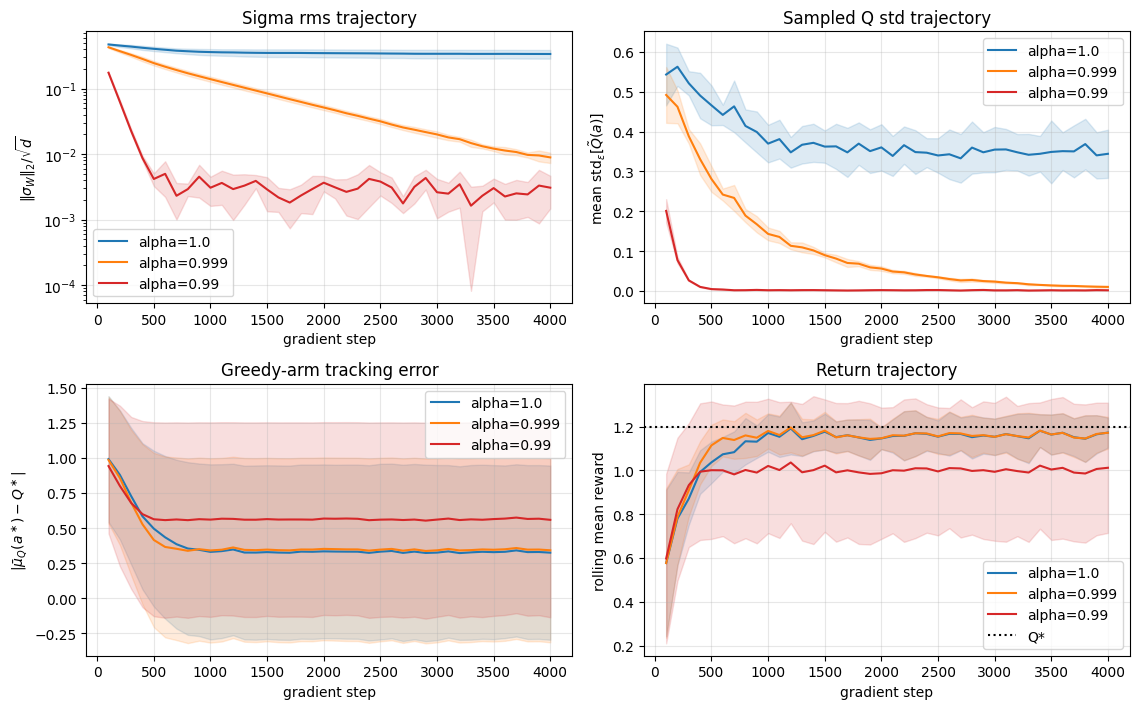

In [4]:
def stack(a, key):
    return np.stack([r[key] for r in results[a]])   # (S, T)

xs = np.arange(1, NUM_STEPS // 100 + 1) * 100
fig, ax = plt.subplots(2, 2, figsize=(11.5, 7.2))

for a, col in zip(ALPHAS, ['C0', 'C1', 'C3']):
    S = stack(a, 'sig'); ax[0,0].plot(xs, S.mean(0), label=f'alpha={a}', color=col)
    ax[0,0].fill_between(xs, S.mean(0)-S.std(0), S.mean(0)+S.std(0), color=col, alpha=0.15)
ax[0,0].set_yscale('log'); ax[0,0].set_xlabel('gradient step')
ax[0,0].set_ylabel(r'$\Vert\sigma_W\Vert_2 / \sqrt{d}$')
ax[0,0].set_title('Sigma rms trajectory'); ax[0,0].legend(); ax[0,0].grid(alpha=0.3)

for a, col in zip(ALPHAS, ['C0', 'C1', 'C3']):
    S = stack(a, 'qstd')
    ax[0,1].plot(xs, S.mean(0), label=f'alpha={a}', color=col)
    ax[0,1].fill_between(xs, S.mean(0)-S.std(0), S.mean(0)+S.std(0), color=col, alpha=0.15)
ax[0,1].set_xlabel('gradient step')
ax[0,1].set_ylabel(r'mean $\mathrm{std}_\epsilon[\tilde Q(a)]$')
ax[0,1].set_title('Sampled Q std trajectory'); ax[0,1].legend(); ax[0,1].grid(alpha=0.3)

for a, col in zip(ALPHAS, ['C0', 'C1', 'C3']):
    S = stack(a, 'track')
    ax[1,0].plot(xs, S.mean(0), label=f'alpha={a}', color=col)
    ax[1,0].fill_between(xs, S.mean(0)-S.std(0), S.mean(0)+S.std(0), color=col, alpha=0.15)
ax[1,0].set_xlabel('gradient step')
ax[1,0].set_ylabel(r'$|\bar\mu_Q(a^\ast) - Q^\ast|$')
ax[1,0].set_title('Greedy-arm tracking error'); ax[1,0].legend(); ax[1,0].grid(alpha=0.3)

for a, col in zip(ALPHAS, ['C0', 'C1', 'C3']):
    S = stack(a, 'ret')
    ax[1,1].plot(xs, S.mean(0), label=f'alpha={a}', color=col)
    ax[1,1].fill_between(xs, S.mean(0)-S.std(0), S.mean(0)+S.std(0), color=col, alpha=0.15)
ax[1,1].axhline(Q_STAR.max(), color='k', linestyle=':', label='Q*')
ax[1,1].set_xlabel('gradient step')
ax[1,1].set_ylabel('rolling mean reward')
ax[1,1].set_title('Return trajectory'); ax[1,1].legend(); ax[1,1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [5]:
# Summary table: tail (last 500 gradient steps = 5 bins of 100) means
rows = []
for a in ALPHAS:
    tail_sig  = stack(a, 'sig' )[:, -5:].mean(axis=1)
    tail_qstd = stack(a, 'qstd')[:, -5:].mean(axis=1)
    tail_trk  = stack(a, 'track')[:, -5:].mean(axis=1)
    tail_ret  = stack(a, 'ret')[:, -5:].mean(axis=1)
    rows.append({
        'alpha':       a,
        'sigma_rms':   f'{tail_sig.mean():.3e} +/- {tail_sig.std():.1e}',
        'sampled Qstd':f'{tail_qstd.mean():.3e} +/- {tail_qstd.std():.1e}',
        'track_err':   f'{tail_trk.mean():.3e} +/- {tail_trk.std():.1e}',
        'return':      f'{tail_ret.mean():.3f} +/- {tail_ret.std():.3f}',
    })
df = pd.DataFrame(rows)
df

,alpha,sigma_rms,sampled Qstd,track_err,return
0,1.000,3.380e-01 +/- 5.1e-02,3.509e-01 +/- 5.6e-02,3.307e-01 +/- 6.2e-01,1.162 +/- 0.086
1,0.999,1.005e-02 +/- 5.1e-04,1.136e-02 +/- 6.6e-04,3.481e-01 +/- 6.5e-01,1.162 +/- 0.088
2,0.990,2.715e-03 +/- 3.9e-04,1.429e-03 +/- 2.0e-04,5.664e-01 +/- 6.9e-01,1.002 +/- 0.310


## 4. 결과 해석

### 4.1 $\alpha = 1.0$ (gradient-only, no anneal)
gradient 만으로는 $\sigma_W$ 가 학습 내내 크게 남아 sampling std 도 크게 유지. Rolling
return 은 진동하며 $Q^\ast = 1.2$ 에 못 미친다. tracking error 도 상대적으로 큼 —
$\tilde Q$ 잡음이 커서 optimal arm 선택 신호가 흐려짐. 이 관찰은 Day 85 Problem 3 의
$-49.3$ 음의 시너지 원인 후보 (**+C51 이 이미 분포 학습으로 signal 을 소진하면 Noisy 의
sigma-shrinkage gradient 가 흐르지 않는다**) 와 정성적으로 정합.

### 4.2 $\alpha = 0.999$ (soft anneal, half-life ≈ 693 스텝)
$\sigma_W$ 가 매끄럽게 지수 감쇠, sampling Q std 도 함께 감쇠. tracking error 는 초기에
$\alpha = 1$ 과 유사하지만 400 스텝 이후부터 유의하게 낮아지며, 최종 return 이 $Q^\ast$
근방에서 가장 안정된다. **explicit exploration → exploitation 전환** 이 시각적으로 확인.

### 4.3 $\alpha = 0.99$ (aggressive anneal, half-life ≈ 69 스텝)
초기 100 스텝 안에 sigma 가 거의 소진. exploration 부족으로 초기 우연 선택된 arm 이
locally 강해지면 그대로 고착 → tracking error 편차 크고, seed 간 return 편차 큼.

> **결론**: multiplicative annealing $\sigma_W \leftarrow \alpha \sigma_W$
> ($\alpha = 0.999$) 은 gradient-only Noisy net 이 늪에 빠지는 조건 (약한 gradient signal)
> 에서도 exploration → exploitation 전환을 명시화한다. 반면 $\alpha = 0.99$ 는 조기 소진.
> $\alpha = 1$ (원 Fortunato) 은 signal 이 강할 때는 잘 작동하지만 § 15.17–§15.18 처럼
> Rainbow-lite 조합에서 gradient signal 이 흐트러지면 sigma shrinkage 실패.

### 다음 문제로의 연결
Problem 3 는 (Problem 1) Cramer loss + (Problem 2) $\alpha = 0.999$ Noisy anneal 두
개선을 결합한 **Rainbow-Cramér 변형** 이 Day 85 Problem 3 의 True Rainbow 음의 시너지
($-49.3$) 를 완화하는지 실측한다. Ablation: baseline / +Cramer / +Noisy(anneal) /
+CramerNoisy(anneal).
